In [5]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    entropy = -np.sum(probs * np.log2(probs + 1e-9)) 
    return entropy

def calculate_info_gain(y, y_left, y_right):
    
    parent_entropy = entropy(y)
    
    n = len(y)
    n_left = len(y_left)
    n_right = len(y_right)
    weighted_entropy = (n_left / n) * entropy(y_left) \
        + (n_right / n) * entropy(y_right)
    
    # Information Gain
    info_gain = parent_entropy - weighted_entropy
    return info_gain

class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    class Node:
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature          # Feature index for splitting
            self.threshold = threshold      # Threshold value for the split
            self.left = left                # Left subtree (Node)
            self.right = right              # Right subtree (Node)
            self.value = value              # Class label for a leaf node

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gain = -1
        split_feature = None
        split_threshold = None
        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])

            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = X[:, feature_idx] > threshold
                y_left, y_right = y[left_mask], y[right_mask]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gain = calculate_info_gain(y, y_left, y_right)

                if gain > best_gain:
                    best_gain = gain
                    split_feature = feature_idx
                    split_threshold = threshold
        return split_feature, split_threshold, best_gain

    def _build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        num_classes = len(np.unique(y))

        if (depth >= self.max_depth or num_classes == 1 or n_samples < self.min_samples_split):
            leaf_value = np.argmax(np.bincount(y))
            return self.Node(value=leaf_value)

        feature, threshold, gain = self._best_split(X, y)

        if gain == -1:  # No split improves the current node
            leaf_value = np.argmax(np.bincount(y))
            return self.Node(value=leaf_value)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return self.Node(feature=feature, threshold=threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

    
iris = load_iris()
X = iris.data  
y = iris.target 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTree(max_depth=4, min_samples_split=2)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on the Iris dataset:", accuracy)

print("Predicted labels:", y_pred)
print("True labels:", y_test)

def print_tree(node, feature_names, depth=0, side="Root"):
    indent = "    " * depth  # Indentation for better readability
    if node.value is not None:
        print(f"{indent}└── [{side}] Leaf: Predict class {node.value}")
    else:
        print(f"{indent}└── [{side}] Feature '{feature_names[node.feature]}' <= {node.threshold:.4f}")
        
        print_tree(node.left, feature_names, depth + 1, side="Left")
        print_tree(node.right, feature_names, depth + 1, side="Right")

feature_names = iris.feature_names
print_tree(tree.tree, feature_names)


Accuracy on the Iris dataset: 1.0
Predicted labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
True labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
└── [Root] Feature 'petal length (cm)' <= 1.9000
    └── [Left] Leaf: Predict class 0
    └── [Right] Feature 'petal length (cm)' <= 4.7000
        └── [Left] Feature 'petal width (cm)' <= 1.6000
            └── [Left] Leaf: Predict class 1
            └── [Right] Leaf: Predict class 2
        └── [Right] Feature 'petal width (cm)' <= 1.7000
            └── [Left] Feature 'petal length (cm)' <= 4.9000
                └── [Left] Leaf: Predict class 1
                └── [Right] Leaf: Predict class 2
            └── [Right] Feature 'petal length (cm)' <= 4.8000
                └── [Left] Leaf: Predict class 2
                └── [Right] Leaf: Predict class 2


Accuracy on the Iris dataset: 1.0
Predicted labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
True labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


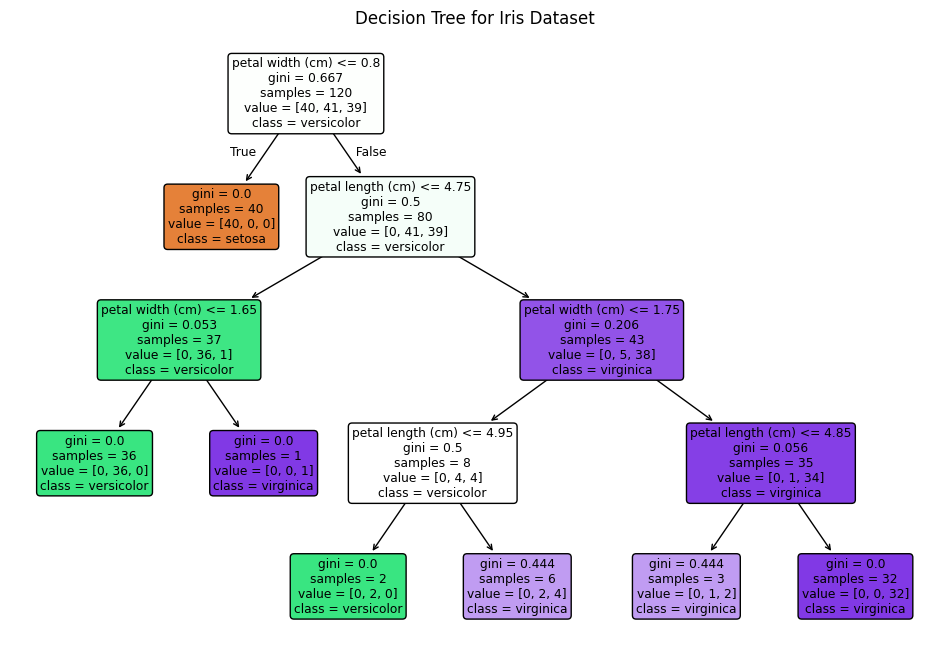

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data  
y = iris.target 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=4, min_samples_split=2)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on the Iris dataset:", accuracy)

print("Predicted labels:", y_pred)
print("True labels:", y_test)

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, 
          feature_names=iris.feature_names, 
          class_names=iris.target_names, 
          filled=True, 
          rounded=True)
plt.title("Decision Tree for Iris Dataset")
plt.show()